In [2]:
# %%
# ============================================================
# 9회차 실습 — 회귀분석: X가 변하면 Y는 얼마나 변할까?
# ============================================================
# 필요한 도구(라이브러리)를 불러옵니다.
# pandas  : 데이터를 표 형태로 다루는 도구
# matplotlib : 그래프를 그리는 도구
# statsmodels : 회귀분석을 수행하는 도구
# seaborn : 좀 더 예쁜 그래프를 그리는 도구

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns


✅ 라이브러리 로드 완료
✅ 데이터 로드 완료
   행(관측치) 수: 132개
   기간: 2015-01 ~ 2025-12
=== 기초 통계량 ===


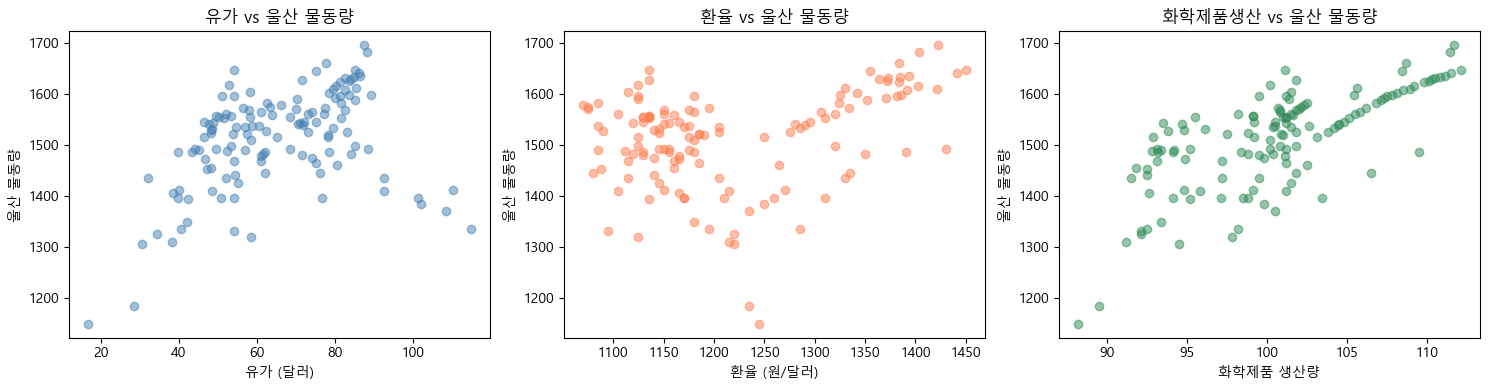

                            OLS Regression Results                            
Dep. Variable:                  Ulsan   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     22.87
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           4.62e-06
Time:                        18:59:03   Log-Likelihood:                -777.97
No. Observations:                 132   AIC:                             1560.
Df Residuals:                     130   BIC:                             1566.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1378.4077     28.823     47.824      0.0

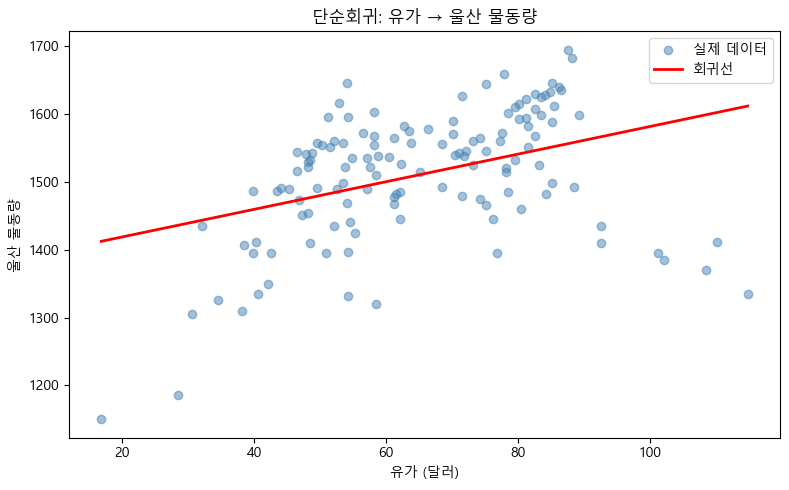

                            OLS Regression Results                            
Dep. Variable:                  Ulsan   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     65.87
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           7.94e-26
Time:                        18:59:03   Log-Likelihood:                -727.05
No. Observations:                 132   AIC:                             1462.
Df Residuals:                     128   BIC:                             1474.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.7279    121.263      0.550      0.5

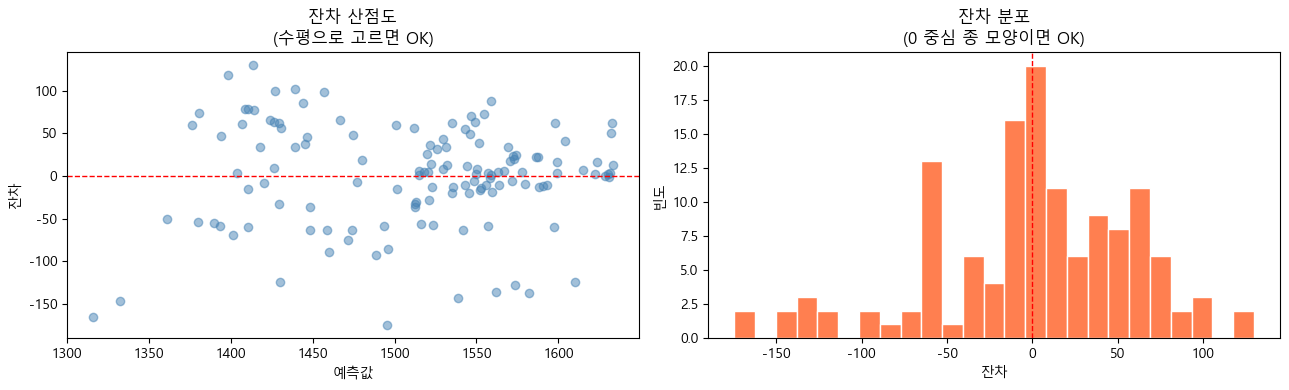


  👀 확인 포인트:
  왼쪽 그래프: 점들이 빨간 점선(0) 주변에 고르게 퍼져 있는가?
    → 한쪽으로 몰려 있거나 패턴이 보이면 모델 재검토 신호
  오른쪽 그래프: 0을 중심으로 좌우 대칭에 가까운가?
    → 한쪽으로 치우쳐 있으면 이상값이 있다는 신호

✅ 9회차 실습 완료!


In [ ]:

# 한글 깨짐 방지 설정 (Colab 환경)
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트 설정

# 폰트 설치가 필요한 경우 아래 두 줄을 먼저 실행하세요
# !apt-get install -y fonts-nanum
# !fc-cache -fv

print("✅ 라이브러리 로드 완료")


# %%
# ============================================================
# STEP 1. 데이터 불러오기
# ============================================================
# 구글 드라이브에서 불러오거나, Colab에 직접 업로드 후 경로 수정
# 아래는 Colab에 파일을 직접 업로드했을 때의 경로 예시입니다

#from google.colab import files
#uploaded = files.upload()  # 파일 선택 창이 뜨면 data.csv를 선택하세요

df = pd.read_csv('data.csv')

# 날짜 컬럼을 날짜 형식으로 변환 (나중에 시계열 분석에서 필요)
df['Date'] = pd.to_datetime(df['Date'])

# 컬럼명에 공백/특수문자가 있어서 다루기 쉽게 정리합니다
df.columns = ['Date', 'Ulsan', 'Daesan', 'Gwangyang',
              'Oil_Price', 'Ex_Rate', 'Chem_Prod',
              'Freight_Idx', 'Global_Idx']

print("✅ 데이터 로드 완료")
print(f"   행(관측치) 수: {len(df)}개")
print(f"   기간: {df['Date'].min().strftime('%Y-%m')} ~ {df['Date'].max().strftime('%Y-%m')}")
df.head()  # 상위 5줄 확인



=== 기초 통계량 ===


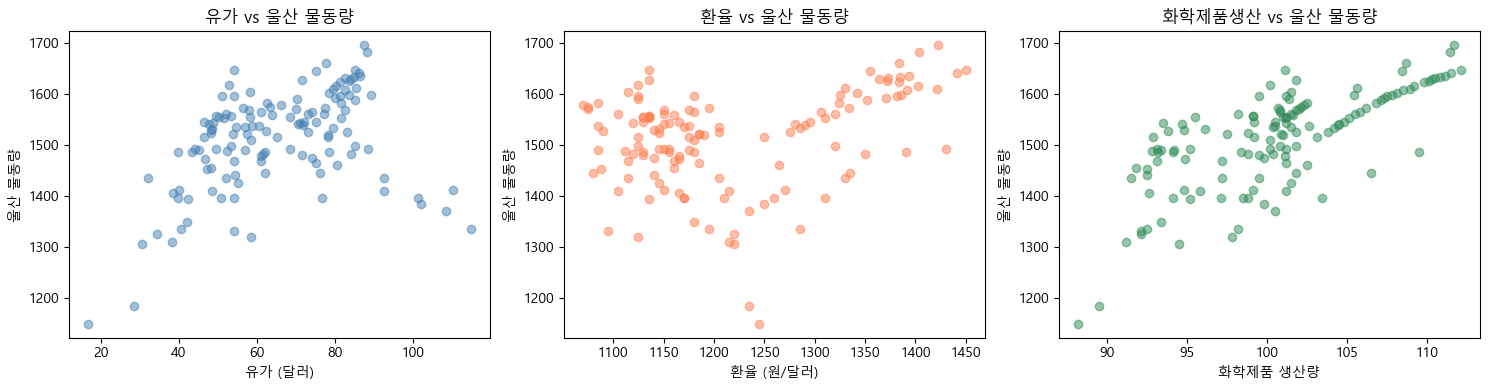

                            OLS Regression Results                            
Dep. Variable:                  Ulsan   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     22.87
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           4.62e-06
Time:                        19:59:09   Log-Likelihood:                -777.97
No. Observations:                 132   AIC:                             1560.
Df Residuals:                     130   BIC:                             1566.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1378.4077     28.823     47.824      0.0

In [6]:

# %%
# ============================================================
# STEP 2. 데이터 훑어보기
# ============================================================
# 분석 전에 항상 데이터를 먼저 눈으로 확인합니다.
# describe()는 평균, 표준편차, 최솟값, 최댓값을 한번에 보여줍니다.

print("=== 기초 통계량 ===")
df.describe().round(2)


# %%
# ============================================================
# STEP 3. 산점도 — 회귀분석 전에 눈으로 먼저 확인
# ============================================================
# 회귀분석을 하기 전에, X와 Y의 관계를 그래프로 먼저 봅니다.
# "직선 관계가 있어 보이는가?" 를 확인하는 것입니다.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 유가 vs 울산 물동량
axes[0].scatter(df['Oil_Price'], df['Ulsan'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('유가 (달러)')
axes[0].set_ylabel('울산 물동량')
axes[0].set_title('유가 vs 울산 물동량')

# 환율 vs 울산 물동량
axes[1].scatter(df['Ex_Rate'], df['Ulsan'], alpha=0.5, color='coral')
axes[1].set_xlabel('환율 (원/달러)')
axes[1].set_ylabel('울산 물동량')
axes[1].set_title('환율 vs 울산 물동량')

# 화학제품생산 vs 울산 물동량
axes[2].scatter(df['Chem_Prod'], df['Ulsan'], alpha=0.5, color='seagreen')
axes[2].set_xlabel('화학제품 생산량')
axes[2].set_ylabel('울산 물동량')
axes[2].set_title('화학제품생산 vs 울산 물동량')

plt.tight_layout()
plt.show()

# ✅ 확인 포인트:
# - 점들이 대략 직선 방향으로 흩어져 있으면 → 회귀분석 적합
# - 완전히 무작위로 흩어져 있으면 → 관계가 약하다는 신호


# %%
# ============================================================
# STEP 4. 단순회귀 — X 하나 (유가 → 울산 물동량)
# ============================================================
# 가장 기본적인 회귀분석입니다.
# "유가(X) 하나만으로 울산 물동량(Y)을 설명해보자"

# Y (종속변수): 울산 물동량
Y = df['Ulsan']

# X (독립변수): 유가
# sm.add_constant()는 절편(β₀)을 자동으로 추가해 주는 함수입니다
# 이것을 빠뜨리면 절편 없이 원점을 지나는 직선을 강제로 긋게 됩니다
X_simple = sm.add_constant(df['Oil_Price'])

# 회귀분석 실행
model_simple = sm.OLS(Y, X_simple).fit()

# 결과 출력
print(model_simple.summary())


In [ ]:

_
# %%
# ============================================================
# STEP 4-1. 단순회귀 결과 — 핵심만 뽑아서 보기
# ============================================================
# summary()의 전체 출력이 복잡하게 느껴질 수 있습니다.
# 우리가 봐야 할 핵심 숫자만 따로 뽑아봅니다.

print("=" * 45)
print("  단순회귀 결과 요약 (유가 → 울산 물동량)")
print("=" * 45)

coef = model_simple.params       # 계수 (β)
pval = model_simple.pvalues      # p-value
r2   = model_simple.rsquared     # R²

print(f"\n  절편(β₀)    : {coef['const']:.2f}")
print(f"  유가 계수(β₁): {coef['Oil_Price']:.4f}")
print(f"  유가 p-value : {pval['Oil_Price']:.4f}")
print(f"  R²           : {r2:.4f}")

print("\n  해석:")
if pval['Oil_Price'] < 0.05:
    print(f"  → 유가는 통계적으로 유의합니다 (p < 0.05)")
else:
    print(f"  → 유가는 통계적으로 유의하지 않습니다 (p ≥ 0.05)")

direction = "증가" if coef['Oil_Price'] > 0 else "감소"
print(f"  → 유가가 1달러 오르면 울산 물동량은 평균 {abs(coef['Oil_Price']):.2f} {direction}")
print(f"  → 이 모델은 울산 물동량 변동의 {r2*100:.1f}%를 설명합니다")


# %%
# ============================================================
# STEP 4-2. 단순회귀 직선 시각화
# ============================================================
# 회귀분석이 어떤 직선을 그었는지 눈으로 확인합니다.

plt.figure(figsize=(8, 5))

# 산점도
plt.scatter(df['Oil_Price'], df['Ulsan'],
            alpha=0.5, color='steelblue', label='실제 데이터')

# 회귀선 (모델이 찾은 직선)
import numpy as np
x_line = np.linspace(df['Oil_Price'].min(), df['Oil_Price'].max(), 100)
y_line = model_simple.params['const'] + model_simple.params['Oil_Price'] * x_line
plt.plot(x_line, y_line, color='red', linewidth=2, label='회귀선')

plt.xlabel('유가 (달러)')
plt.ylabel('울산 물동량')
plt.title('단순회귀: 유가 → 울산 물동량')
plt.legend()
plt.tight_layout()
plt.show()


# %%
# ============================================================
# STEP 5. 다중회귀 — X 여러 개 (유가 + 환율 + 화학제품생산)
# ============================================================
# 현실에서 울산 물동량은 유가만의 영향을 받지 않습니다.
# 여러 변수를 동시에 넣어서 각각의 영향을 분리합니다.

X_multi = sm.add_constant(df[['Oil_Price', 'Ex_Rate', 'Chem_Prod']])

model_multi = sm.OLS(Y, X_multi).fit()

print(model_multi.summary())


# %%
# ============================================================
# STEP 5-1. 다중회귀 결과 — 핵심만 뽑아서 보기
# ============================================================

print("=" * 50)
print("  다중회귀 결과 요약")
print("  (유가 + 환율 + 화학제품생산 → 울산 물동량)")
print("=" * 50)

coef_m = model_multi.params
pval_m = model_multi.pvalues
r2_m   = model_multi.rsquared

variables = ['Oil_Price', 'Ex_Rate', 'Chem_Prod']
labels    = ['유가', '환율', '화학제품생산']

for var, label in zip(variables, labels):
    sig = "✅ 유의" if pval_m[var] < 0.05 else "❌ 유의하지 않음"
    direction = "↑" if coef_m[var] > 0 else "↓"
    print(f"\n  [{label}]")
    print(f"    계수    : {coef_m[var]:.4f}  {direction}")
    print(f"    p-value : {pval_m[var]:.4f}  {sig}")

print(f"\n  R² : {r2_m:.4f}  → 변동의 {r2_m*100:.1f}%를 설명")


# %%
# ============================================================
# STEP 6. 단순회귀 vs 다중회귀 비교
# ============================================================
# 변수를 추가하면 결과가 어떻게 달라지는지 나란히 비교합니다.

print("=" * 55)
print("  단순회귀 vs 다중회귀 비교")
print("=" * 55)
print(f"  {'항목':<20} {'단순회귀':>12} {'다중회귀':>12}")
print("-" * 55)
print(f"  {'유가 계수':<20} {model_simple.params['Oil_Price']:>12.4f} {model_multi.params['Oil_Price']:>12.4f}")
print(f"  {'유가 p-value':<20} {model_simple.pvalues['Oil_Price']:>12.4f} {model_multi.pvalues['Oil_Price']:>12.4f}")
print(f"  {'R²':<20} {model_simple.rsquared:>12.4f} {model_multi.rsquared:>12.4f}")
print("=" * 55)

print("""
  👀 비교 포인트:
  - 유가 계수가 단순회귀와 다중회귀에서 달라졌나요?
    → 달라졌다면: 유가 외 다른 변수들이 유가와 함께
      울산 물동량에 영향을 주고 있었다는 뜻입니다.
  - R²가 올라갔나요?
    → 올라갔다면: 변수를 추가해서 설명력이 높아진 것입니다.
""")


# %%
# ============================================================
# STEP 7. 잔차 확인 — 모델이 놓친 것이 있는가?
# ============================================================
# 잔차에 패턴이 없어야 좋은 모델입니다.
# 두 가지 그래프로 확인합니다.

residuals = model_multi.resid  # 잔차 추출

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 그래프 1: 잔차 산점도 (예측값 vs 잔차)
# 가로축: 모델이 예측한 값 / 세로축: 잔차
# → 수평으로 고르게 퍼져 있으면 OK
axes[0].scatter(model_multi.fittedvalues, residuals,
                alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('예측값')
axes[0].set_ylabel('잔차')
axes[0].set_title('잔차 산점도\n(수평으로 고르면 OK)')

# 그래프 2: 잔차 분포 히스토그램
# → 가운데(0)를 중심으로 종 모양이면 OK
axes[1].hist(residuals, bins=25, color='coral', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('잔차')
axes[1].set_ylabel('빈도')
axes[1].set_title('잔차 분포\n(0 중심 종 모양이면 OK)')

plt.tight_layout()
plt.show()

print("""
  👀 확인 포인트:
  왼쪽 그래프: 점들이 빨간 점선(0) 주변에 고르게 퍼져 있는가?
    → 한쪽으로 몰려 있거나 패턴이 보이면 모델 재검토 신호
  오른쪽 그래프: 0을 중심으로 좌우 대칭에 가까운가?
    → 한쪽으로 치우쳐 있으면 이상값이 있다는 신호
""")

print("✅ 9회차 실습 완료!")